{'username': '小黄', 'greeting': 'Dear 小黄', 'output': 'Dear 小黄，你好！'}
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	node_a --> node_b;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



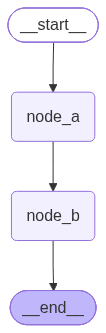

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class OverAllState(TypedDict):
    username: str
    greeting: str
    output: str

def node_a(state: OverAllState) -> OverAllState:
    return {
        "greeting": "Dear " + state["username"]
    }

def node_b(state: OverAllState) -> OverAllState:
    return {
        "output": state["greeting"] + "，你好！"
    }

builder = StateGraph(state_schema=OverAllState)
# builder.add_node("node_a", node_a)
# builder.add_node("node_b", node_b)
# builder.add_edge(START, "node_a")
# builder.add_edge("node_a", "node_b")
# builder.add_edge("node_b", END)
builder.add_edge(START,"node_a")
builder.add_sequence([node_a,node_b]) # 串联结构的简便写法
# builder.add_edge("node_b",END) # END可以省略，但分支/跳转/循环的场景下必须写，建议写

graph = builder.compile()
res = graph.invoke({"username": "小黄"})
print(res)

from IPython.display import display
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
display(graph)